###Μηχανική Μάθηση
####2η ατομική εργασία
ΣΗΜΜΥ- ΕΜΠ - 7ο εξάμηνο -Ακ. Έτος 2025-26



# ⚠️
`Επισημαίνεται ότι απαγορεύεται η ανάρτηση των λύσεων των εργαστηριακών ασκήσεων στο github, ή σε άλλες ιστοσελίδες. Η σχεδίαση και το περιεχόμενο των εργαστηριακών projects αποτελούν αντικείμενο πνευματικής ιδιοκτησίας της διδακτικής ομάδας του μαθήματος.`

### Εισαγωγή

Στην άσκηση αυτή θα εξερευνήσετε τεχνικές συσταδοποίησης και μείωσης διαστατικότητας σε εικόνες, ξεκινώντας από υπερφασματικά δεδομένα και προχωρώντας σε δεδομένα τηλεπισκόπησης.

- **Μέρος 1**: Θα χρησιμοποιήσετε τη μέθοδο συσταδοποίησης **k-means**, καθώς και την **fuzzy c-means**, σε συνδυασμό με τη μέθοδο μείωσης διαστατικότητας **PCA**, για την ανάλυση μιας υπερφασματικής εικόνας.

- **Μέρος 2**: Θα εργαστείτε με ένα σύνολο δεδομένων τηλεπισκόπησης και, με τη βοήθεια ενός προεκπαιδευμένου CNN, θα εξάγετε χαρακτηριστικά εικόνων για συσταδοποίηση, συγκρίνοντας τα αποτελέσματα με τη συσταδοποίηση με χρήση των pixels.

Ονοματεπώνυμο φοιτητή: Γεώργιος Κωνσταντόπουλος

Α.Μ.: 03122104

### 1. Φόρτωση υπερφασματικής εικόνας και των επισημειώσεων της

Κατεβάστε την υπερφασματική εικόνα `indian_pines_corrected.npy` και τις αντίστοιχες επισημειώσεις `indian_pines_gt.npy` από το Google Drive:
https://drive.google.com/drive/folders/1DQiI75ll5h79-UTaq_nmcwfz4h3cxDVM?usp=sharing

1.α. Φορτώστε την εικόνα και τις αντίστοιχες επισημειώσεις με χρήση της συνάρτησης np.load.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

indian_pines_corrected = np.load('indian_pines_corrected.npy')
indian_pines_gt = np.load('indian_pines_gt.npy')

Οι επισημειώσεις που φορτώσατε αντιστοιχούν κάθε πιξελ της υπερφασματικής εικόνας σε ένα τύπο από διαφορετικές κατηγορίες:

```python
classes = [
    "Undefined",
    "Alfalfa",
    "Corn-notill",
    "Corn-mintill",
    "Corn",
    "Grass-pasture",
    "Grass-trees",
    "Grass-pasture-mowed",
    "Hay-windrowed",
    "Oats",
    "Soybean-notill",
    "Soybean-mintill",
    "Soybean-clean",
    "Wheat",
    "Woods",
    "Buildings-Grass-Trees-Drives",
    "Stone-Steel-Towers"
]
```

### 2. Οπτικοποίηση και Διερευνητική ανάλυση δεδομένων

Παρουσιάστε με χρήση κώδικα πληροφορίες για τα εξής:

2α. Βρείτε το ύψος και το πλάτος της εικόνας, καθώς και τον αριθμό των υπερφασματικών καναλιών

2β. Σχεδιάστε με χρήση της matplotlib το 3ο, 65ο, και 95ο κανάλι της εικόνας στο ίδιο διάγραμμα

2γ. Υπολογίστε τον αριθμό των διαφορετικών κατηγοριών καλλιέργειας στις επισημειώσεις

2δ. Σχεδιάστε με χρήση της matplotlib τις επισημειώσεις. Προσθέστε επιπλέον επεξηγηματική λεζάντα με χρήση της βιβλιοθήκης κάθε επισημείωσης (χρησιμοποιήστε τη λίστα `classes` που σας δόθηκε προηγουμένως.)

2ε. Υπολογίστε πόσα pixel της εικόνας αντιστοιχούν σε κάθε επισημείωση.

Ύψος εικόνας: 145
Πλάτος εικόνας: 145
Αριθμός υπερφασματικών καναλιών: 200


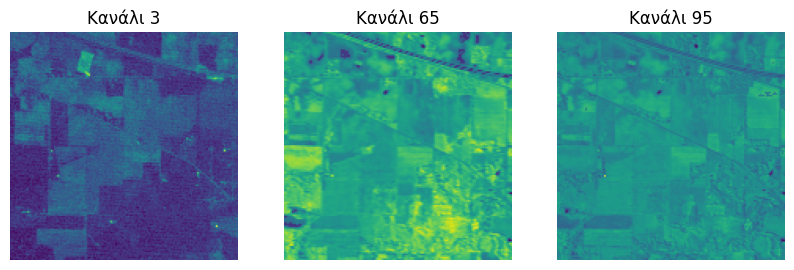

Αριθμός διαφορετικών κατηγοριών καλλιέργειας: 17


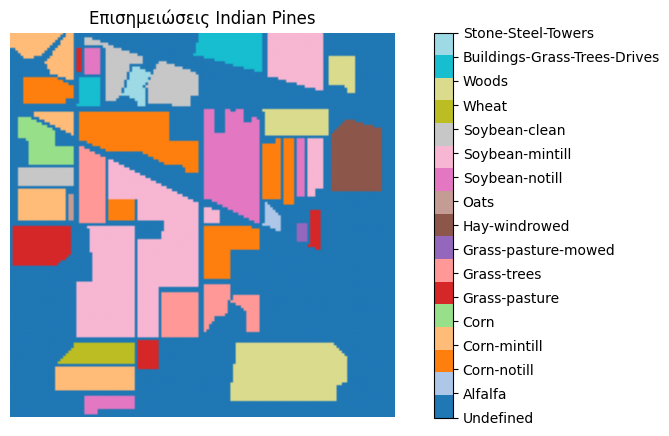

Αριθμός pixel ανά επισημείωση:
Undefined: 10776 pixels
Alfalfa: 46 pixels
Corn-notill: 1428 pixels
Corn-mintill: 830 pixels
Corn: 237 pixels
Grass-pasture: 483 pixels
Grass-trees: 730 pixels
Grass-pasture-mowed: 28 pixels
Hay-windrowed: 478 pixels
Oats: 20 pixels
Soybean-notill: 972 pixels
Soybean-mintill: 2455 pixels
Soybean-clean: 593 pixels
Wheat: 205 pixels
Woods: 1265 pixels
Buildings-Grass-Trees-Drives: 386 pixels
Stone-Steel-Towers: 93 pixels


In [2]:
#2a Height, width and number of dimensions of image
height, width, num_channels = indian_pines_corrected.shape
print(f"Ύψος εικόνας: {height}")
print(f"Πλάτος εικόνας: {width}")
print(f"Αριθμός υπερφασματικών καναλιών: {num_channels}")

#2b Plot the 3rd, 65th and 95th channel of the image
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

#3rd channel
axes[0].imshow(indian_pines_corrected[:, :, 2])
axes[0].set_title('Κανάλι 3')
axes[0].axis('off')

#65th channel
axes[1].imshow(indian_pines_corrected[:, :, 64])
axes[1].set_title('Κανάλι 65')
axes[1].axis('off')

#95th channel
axes[2].imshow(indian_pines_corrected[:, :, 94])
axes[2].set_title('Κανάλι 95')
axes[2].axis('off')

plt.show()

#2c Calculate the number of different kinds of crops
unique_classes=np.unique(indian_pines_gt)
num_unique_classes=len(unique_classes)
print(f"Αριθμός διαφορετικών κατηγοριών καλλιέργειας: {num_unique_classes}")

#2d Plot Annotations with Legend
classes = [
    "Undefined",
    "Alfalfa",
    "Corn-notill",
    "Corn-mintill",
    "Corn",
    "Grass-pasture",
    "Grass-trees",
    "Grass-pasture-mowed",
    "Hay-windrowed",
    "Oats",
    "Soybean-notill",
    "Soybean-mintill",
    "Soybean-clean",
    "Wheat",
    "Woods",
    "Buildings-Grass-Trees-Drives",
    "Stone-Steel-Towers"
]
#Colormap for annotations
cmap=plt.get_cmap('tab20', len(classes))

plt.figure(figsize=(10, 5))
img=plt.imshow(indian_pines_gt, cmap=cmap)
plt.title('Επισημειώσεις Indian Pines')
plt.axis('off')

cbar=plt.colorbar(img, ticks=np.arange(len(classes)))
cbar.ax.set_yticklabels(classes)

plt.show()

#2e Calculate how many pixels per annotation
unique_labels, counts=np.unique(indian_pines_gt, return_counts=True)

print("Αριθμός pixel ανά επισημείωση:")
for i in range(len(unique_labels)):
    label = unique_labels[i]
    print(f"{classes[label]}: {counts[i]} pixels")

### 3. Εύρεση φασματικών υπογραφών

3.α. Μετατρέψτε την υπερφασματική εικόνα και τις επισημειώσεις σε μορφή κατάλληλη για περαιτέρω επεξεργασία. Η εικόνα θα πρέπει να μετατραπεί σε πίνακα N x Κ, όπου Ν τα pixel και K ο αριθμός των καναλιών. Οι επισημειώσεις αντίστοιχα θα πρέπει να μετατραπούν σε διάνυσμα μήκους Ν. Στη συνέχεια, "διώχτε" όσα δεδομένα είναι επισημειωμένα ως Undefined.

💡 Χρησιμοποιήστε την `numpy reshape`

In [3]:
#N=145*145 (height*width), K=200
hyperimage=np.reshape(indian_pines_corrected, ((145*145, 200)))
annotations=np.reshape(indian_pines_gt, (145*145))
print(hyperimage.shape)

#Remove Undefined
hyperimage=hyperimage[annotations!=0]
annotations=annotations[annotations!=0]
print(hyperimage.shape)

(21025, 200)
(10249, 200)


3.β. Επιλέξτε ένα τυχαίο pixel της εικόνα από κάθε κατηγορία, και σχεδιάστε την υπερφασματική υπογραφή των επιλεγμένων πίξελ.

Η υπερφασματική υπογραφή είναι ουσιαστικά η καμπύλη που δείχνει πόσο φως ανακλά ένα υλικό σε κάθε ένα από τα κανάλια της εικόνας, δηλαδή το σύνολο των τιμών που καταγράφει ο αισθητήρας σε πολλά διαφορετικά μήκη κύματος για το ίδιο ακριβώς σημείο της εικόνας.

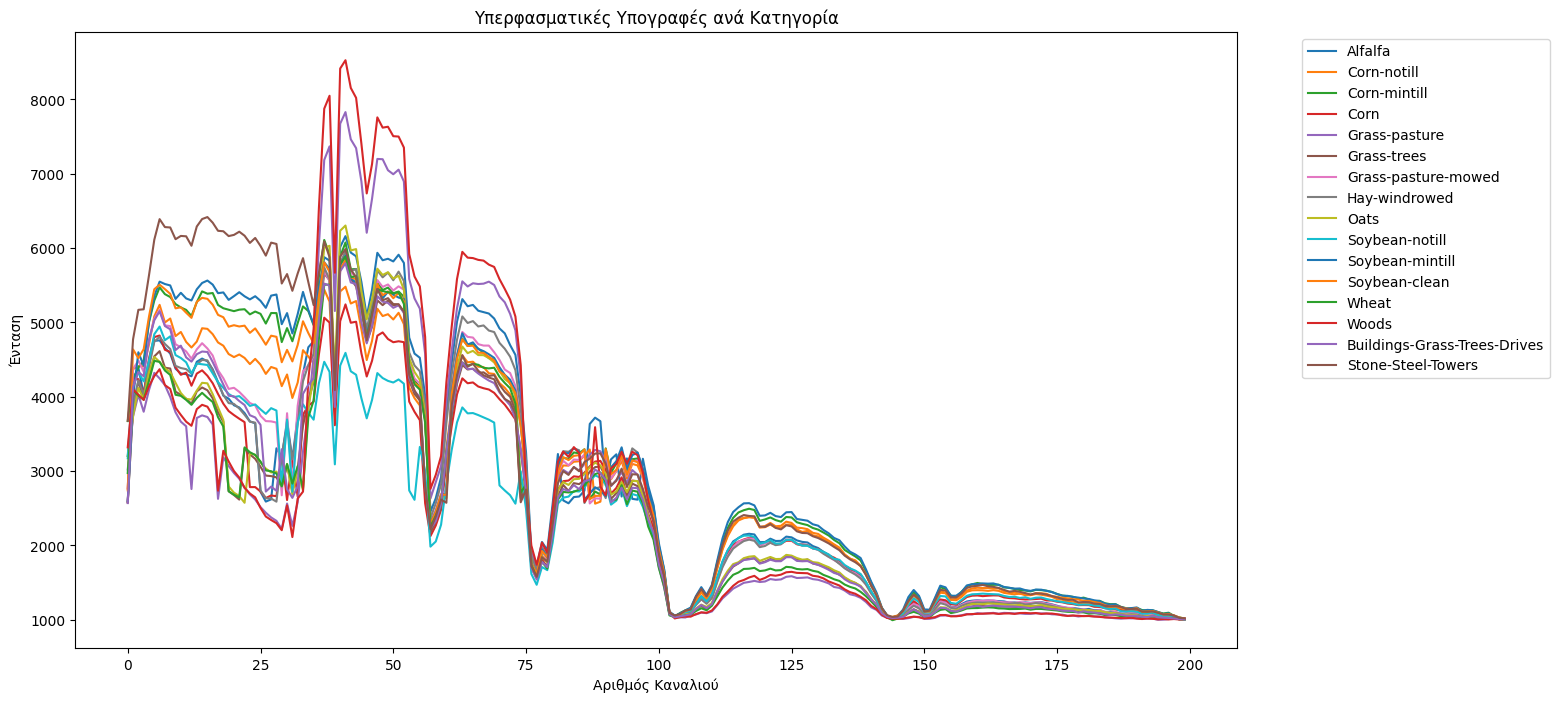

In [4]:
plt.figure(figsize=(15, 8))
unique_categories=np.unique(annotations)

for category_id in unique_categories:
    indices=np.where(annotations == category_id)[0]
    random_pixel_index=np.random.choice(indices)
    spectral_signature=hyperimage[random_pixel_index, :]
    plt.plot(spectral_signature, label=classes[category_id])

plt.title('Υπερφασματικές Υπογραφές ανά Κατηγορία')
plt.xlabel('Αριθμός Καναλιού')
plt.ylabel('Ένταση')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

3.γ. Σημειώστε τις παρατηρήσεις σας και τα συμπεράσματα σας. Προσπαθήστε να απαντήσετε στις ακόλουθες ερωτήσεις:
    
* Με βάση τα προηγούμενα διαγράμματα θεωρείτε ότι κάποιες καλλιέργειες είναι πιο εύκολα διαχωρίσιμες από άλλες με βάση τη φασματική υπογραφή τους;
* Θεωρείτε ότι όλα τα κανάλια παρέχουν χρήσιμη πληροφορία για το διαχωρισμό;

>- Από ότι φαίνεται στα περισσότερα κανάλια η κλάση 'Corn' (κόκκινη γραμμή) όπως και η 'Buildings-Grass-Trees-Drives' (μωβ γραμμή), αλλά και η 'Stone-steal-towers' (καφέ γραμμή) είναι πιο διαχωρισμένες από τις υπόλοιπες. Αυτό προφανώς συμβαίνει λόγω των διαφορετικών χρωμάτων που έχουν το καλαμπόκι, τα κτήρια και η πέτρα από τις άλλες κλάσεις που κυρίως χαρακτηρίζονται από πράσινο χρώμα. Για αυτό έχουν και διαφορετική ένταση ανά κανάλι. Συνεπώς, η καλλιέργεια που είναι πιο εύκολα διαχωρίσιμη είναι το καλαμπόκι (Corn).
>- Όχι δεν είναι ιδανικά όλα τα κανάλια για διαχωρισμό. Περισσότερη χρήσιμη πληροφορία για τον διαχωρισμό παίρνουμε στα κανάλια που ανήκουν στο εύρος (30,55), στο (60,75) και λιγότερο στο (110, 130).

3.δ. Σχεδιάστε ένα heatmap, που να δείχνει τη συσχέτιση μεταξύ των διαφορετικών καναλιών

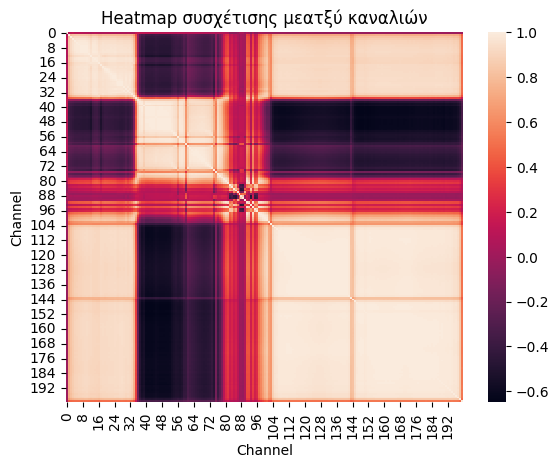

In [5]:
df=pd.DataFrame(hyperimage)
correlation=df.corr()
sns.heatmap(correlation)
plt.title("Heatmap συσχέτισης μεατξύ καναλιών")
plt.xlabel("Channel")
plt.ylabel("Channel")
plt.show()

### 4. Συσταδοποίηση με χρήση του αλγορίθμου KMeans

 4.α. Εφαρμόστε τον αλγόριθμο KMeans (sklearn.cluster) στα δεδομένα (εφόσον κάνατε την προεπεξεργασία του Βήματος 3). Χρησιμοποιήστε την τιμή `n_cluster=17`.

Αξιολογήστε την απόδοση του αλγορίθμου χρησιμοποιώντας τις ακόλουθες μετρικες:

* Adjusted Rand Index
* Silhouette Score

Ο Adjusted Rand Index (ARI) υπολογίζει πόσα ζεύγη σημείων ταξινομήθηκαν σωστά είτε στην ίδια συστάδα είτε σε διαφορετικές συστάδες χρησιμοποιώντας τις πραγματικές κατηγορίες, λαμβάνοντας υπόψη τυχαίες αντιστοιχίσεις. Έχει τιμές από -1 (πολύ κακή συσταδοποίηση) έως 1 (τέλεια ευθυγράμμιση με τις κατηγορίες), ενώ τιμή 0 υποδηλώνει τυχαία συσταδοποίηση. Είναι χρήσιμο για την αξιολόγηση της ακρίβειας σε δεδομένα με γνωστές κατηγορίες.

Αντιθέτως το  Silhouette Score μετρά πόσο καλά ένα σημείο δεδομένων ταιριάζει στη συστάδα του σε σχέση με τις υπόλοιπες συστάδες. Υπολογίζει τη μέση απόσταση ενός σημείου από τα υπόλοιπα σημεία της ίδιας συστάδας (cohesion) και τη μέση απόσταση από τα σημεία της πλησιέστερης άλλης συστάδας (separation). Το σκορ κυμαίνεται από -1 έως 1, όπου τιμές κοντά στο 1 υποδηλώνουν καλά ορισμένες συστάδες, τιμές κοντά στο 0 σημαίνουν αλληλοεπικαλυπτόμενες συστάδες, ενώ αρνητικές τιμές υποδεικνύουν κακή ανάθεση σε συστάδα.

Ο Silhouette Score είναι ένα μέτρο εσωτερικής αξιολόγησης, που εξετάζει τη συνοχή και τον διαχωρισμό των συστάδων χωρίς να λαμβάνει υπόψη πραγματικές κατηγορίες. Αντίθετα, ο Adjusted Rand Index (ARI) είναι μέτρο εξωτερικής αξιολόγησης, που συγκρίνει τις συστάδες με τις πραγματικές κατηγορίες (ground truth). Η χρήση και των δύο μαζί παρέχει μια συνολική εικόνα της ποιότητας της συσταδοποίησης.

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

kmeans=KMeans(n_clusters=17, random_state=42)
y_pred=kmeans.fit_predict(hyperimage)
ari=adjusted_rand_score(annotations, y_pred)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
sil=silhouette_score(hyperimage, y_pred)
print(f"Silhouette Score: {sil:.4f}")

Adjusted Rand Index (ARI): 0.2064
Silhouette Score: 0.2615


4.β. Εφαρμογή του αλγορίθμου Fuzzy C-Means

Ο αλγόριθμος **Fuzzy C-Means** δεν περιλαμβάνεται στο scikit-learn, αλλά μπορούμε να τον εφαρμόσουμε χρησιμοποιώντας τη βιβλιοθήκη `fcmeans`.

#### **Βήμα 1: Εγκατάσταση της βιβλιοθήκης**
Πρώτα, εγκαταστήστε τη βιβλιοθήκη `fcmeans` εκτελώντας την παρακάτω εντολή σε ένα κελί:

```bash
!pip install fuzzy-c-means
```

#### Βήμα 2: Εκτέλεση του αλγορίθμου
Η fcmeans παρέχει λειτουργικότητα αντίστοιχη με τον τρόπο εκπαίδευσης του scikit-learn, επιτρέποντας εύκολη ενσωμάτωση στη ροή εργασιών σας.

Για περισσότερες πληροφορίες σχετικά με τη χρήση της βιβλιοθήκης, δείτε το documentation: https://fuzzy-c-means.readthedocs.io/en/latest/

Υπολογίστε πάλι το Silhouette Score και το ARI και συγκρίνετε με τις προηγούμενες μεθόδους.



In [7]:
!pip install fuzzy-c-means

In [8]:
from fcmeans import FCM
fcm=FCM(n_clusters=17)
fcm.fit(hyperimage)
labels_fcm=fcm.predict(hyperimage)
ari_fcm=adjusted_rand_score(annotations, labels_fcm)
print(f"Adjusted Rand Index (ARI) Fuzzy C-Means: {ari_fcm:.4f}")
sil_fcm=silhouette_score(hyperimage, labels_fcm)
print(f"Silhouette Score Fuzzy C-Means: {sil_fcm:.4f}")

Adjusted Rand Index (ARI) Fuzzy C-Means: 0.1729
Silhouette Score Fuzzy C-Means: 0.1889


### 5. Μείωση διαστατικότητας δεδομένων

5.α. Εφαρμόστε στα δεδομένα τη μέθοδο μείωσης διαστατικότητας PCA. Επιλέξτε `n_components=3`

In [9]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
hyperimage_pca=pca.fit_transform(hyperimage)
print(hyperimage_pca.shape)

(10249, 3)


5.β. Τι ποσοστό της διακύμανσης των δεδομένων διατηρείτε με `n_components=3` ?
Hint: sklearn.decomposition.PCA.explained_variance_ratio_

In [10]:
explained_variance=pca.explained_variance_ratio_
print(f"\nExplained Variance Ratio ανά συνιστώσα: {explained_variance*100}%")
print(f"Ποσοστό διακύμανσης που διατηρείται με n_components=3: {sum(explained_variance)*100:.1f}%")


Explained Variance Ratio ανά συνιστώσα: [66.45271271 26.54257961  1.20619728]%
Ποσοστό διακύμανσης που διατηρείται με n_components=3: 94.2%


>Συνεπώς, πετάξαμε 197 διαστάσεις και κρατήσαμε μόνο 3, αλλά παρόλα αυτά διατηρήσαμε το 94% της αρχικής πληροφορίας της εικόνας.

### 6. Συνδυασμός μείωσης διαστατικότητας και kmeans

6.α. Εφαρμόστε τον αλγόριθμο kmeans στα δεδομένα μειωμένης διαστατικότητας `n_components=3`, και υπολογίστε εκ νέου τις μετρικές. Τι συμπεράσματα βγάζετε;

6.β. Δοκιμάστε διαφορετικές τιμές για το n_components (από 1 έως 5) και τρέχτε εκ νέου κάθε φορα τον k-means, υπολογίζοντας τα τελικά score. Για κάθε μετρική, φτιάχτε ένα διάγραμμα που στον άξονα των Χ θα έχει τον αριθμό n_components και στον άξονα των Υ, την τιμή της μετρικής. Τι συμπεράσματα βγάζετε;

In [11]:
#6a
kmeans_pca=KMeans(n_clusters=17, random_state=42)
kmeans_pca.fit(hyperimage_pca)
y_pred_pca=kmeans_pca.predict(hyperimage_pca)
ari_pca=adjusted_rand_score(annotations, y_pred_pca)
print(f"Adjusted Rand Index (ARI) με PCA: {ari_pca:.4f}")
sil_pca=silhouette_score(hyperimage_pca, y_pred_pca)
print(f"Silhouette Score με PCA: {sil_pca:.4f}")

Adjusted Rand Index (ARI) με PCA: 0.1929
Silhouette Score με PCA: 0.3680


n_components=1: ARI=0.1729, Silhouette=0.5233
n_components=2: ARI=0.1868, Silhouette=0.3833
n_components=3: ARI=0.1929, Silhouette=0.3680
n_components=4: ARI=0.1958, Silhouette=0.3574
n_components=5: ARI=0.1976, Silhouette=0.3511


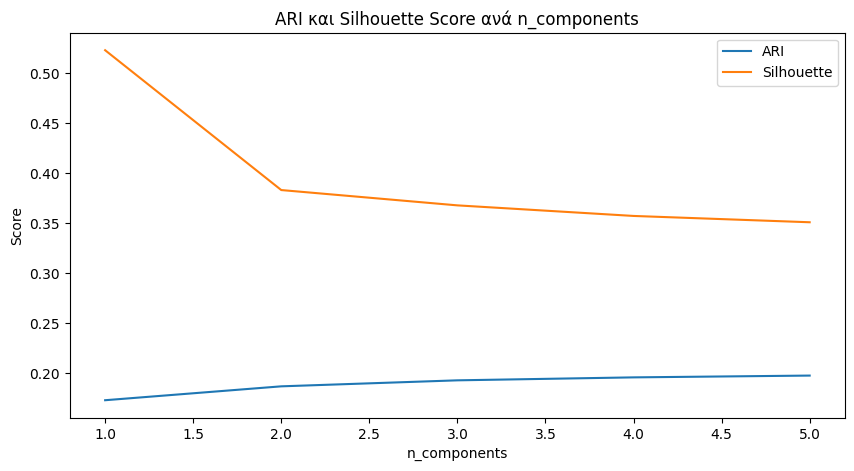

In [12]:
#6b
ari_scores=[]
sil_scores=[]
for n in range(1, 6):
    pca_temp=PCA(n_components=n)
    hyperimage_pca=pca_temp.fit_transform(hyperimage)
    kmeans_temp=KMeans(n_clusters=17, random_state=42)
    kmeans_temp.fit(hyperimage_pca)
    y_pred_temp=kmeans_temp.predict(hyperimage_pca)
    ari_scores.append(adjusted_rand_score(annotations, y_pred_temp))
    sil_scores.append(silhouette_score(hyperimage_pca, y_pred_temp))
    print(f"n_components={n}: ARI={ari_scores[-1]:.4f}, Silhouette={sil_scores[-1]:.4f}")
plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), ari_scores, label='ARI')
plt.plot(range(1, 6), sil_scores, label='Silhouette')
plt.xlabel('n_components')
plt.ylabel('Score')
plt.title('ARI και Silhouette Score ανά n_components')
plt.legend()
plt.show()

> - Το ARI είναι αρκετά χαμηλό (<0.1) για n_components=1 και εμφανίζει απότομη αύξηση για n_components=2 και συνεχίζει να αυξάνεται με τις τιμές του να είναι κοντά στο 0.2. Με λίγα λόγια οι 3 πρώτες κύριες συνιστώσες είναι αυτές που περιέχουν τη σημαντική πληροφορία για τον επιτυχημένο διαχωρισμό των καλλιεργειών. Η προσθήκη περατίτερω διαστάσεων προσθέτει ελάχιστη πληροφορία χωρίς να βελτιώνεται αισθητά το αποτέλεσμα.
> - Όσο για το Sillhouete Score βλέπουμε το αντίθετο. Είναι υψηλό για n_components=1 (>0.5) και απότομα στο n_components=2 μειώνεται στο 0.37 περίπου. Η μετρική αυτή μετράει πόσο διακριτά είναι μεταξύ τους τα διαφορετικά clusters που κατασκευάζει το μοντέλο. Όταν, λοιπόν, υπάρχει μία διάσταση όλα τα δεδομένα προβάλλονται σε μία γραμμή και οι συστάδες δημιουργούν "πυκνές" ομάδες και φαινομενικά η μία συστάδα έχει μεγαλύτερες πιθανότητες να μοιάζει με την άλλη και να βγαίνει φαινομενικά υψηλό το Silhouette Score.

# Μέρος 2: Χρήση προεκπαιδευμένου CNN για συσταδοποίηση

Σε αυτό το μέρος, θα χρησιμοποιήσουμε τη βιβλιοθήκη **Keras**, η οποία παρέχει εύκολη ενσωμάτωση προεκπαιδευμένων μοντέλων CNN και ευκολία στη διαχείριση δεδομένων. Στόχος μας είναι να αναδείξουμε τη δύναμη των χαρακτηριστικών που εξάγονται από προεκπαιδευμένα CNN (Convolutional Neural Networks) για τη συσταδοποίηση δεδομένων τηλεπισκόπησης.

Θα χρησιμοποιήσουμε ένα υποσύνολο από το σύνολο δεδομένων **EuroSAT**, το οποίο αποτελείται από δορυφορικές εικόνες κατανεμημένες σε 10 κατηγορίες (π.χ., καλλιέργειες, δάση, αστικές περιοχές). Τα χαρακτηριστικά που θα εξάγουμε από ένα προεκπαιδευμένο CNN θα χρησιμοποιηθούν για την ομαδοποίηση των εικόνων.

---

## 1. Φόρτωση του συνόλου δεδομένων

Για τους σκοπούς αυτής της άσκησης, θα χρησιμοποιήσουμε το σύνολο δεδομένων **EuroSAT**. Το EuroSAT περιλαμβάνει δορυφορικές εικόνες οργανωμένες σε φακέλους κατά κατηγορία.

---

### 1.α. Κατέβασμα και αποσυμπίεση του EuroSAT

Το EuroSAT δεν υποστηρίζεται απευθείας από το Keras, αλλά μπορείτε να το κατεβάσετε και να το αποσυμπιέσετε με τις παρακάτω εντολές:

```bash
# Κατέβασμα του EuroSAT
!wget https://madm.dfki.de/files/sentinel/EuroSAT.zip --no-check-certificate

# Αποσυμπίεση του αρχείου
!unzip EuroSAT.zip
```

### 1.β. Ενσωμάτωση του Keras μέσω TensorFlow
Η βιβλιοθήκη Keras είναι ενσωματωμένη στο TensorFlow. Για να τη χρησιμοποιήσετε, πρέπει να εισάγετε τη βιβλιοθήκη TensorFlow και να χρησιμοποιήσετε τις κλάσεις της Keras μέσω του tensorflow.keras.

Παρακάτω φαίνεται πώς να φορτώσετε το EuroSAT χρησιμοποιώντας το ImageDataGenerator:


In [13]:
# Κατέβασμα του EuroSAT
!wget https://madm.dfki.de/files/sentinel/EuroSAT.zip --no-check-certificate

# Αποσυμπίεση του αρχείου
!unzip EuroSAT.zip

Streaming output truncated to the last 5000 lines.
  inflating: 2750/SeaLake/SeaLake_2206.jpg  
  inflating: 2750/SeaLake/SeaLake_1313.jpg  
  inflating: 2750/SeaLake/SeaLake_263.jpg  
  inflating: 2750/SeaLake/SeaLake_967.jpg  
  inflating: 2750/SeaLake/SeaLake_515.jpg  
  inflating: 2750/SeaLake/SeaLake_1465.jpg  
  inflating: 2750/SeaLake/SeaLake_1817.jpg  
  inflating: 2750/SeaLake/SeaLake_2902.jpg  
  inflating: 2750/SeaLake/SeaLake_2570.jpg  
  inflating: 2750/SeaLake/SeaLake_1004.jpg  
  inflating: 2750/SeaLake/SeaLake_174.jpg  
  inflating: 2750/SeaLake/SeaLake_2111.jpg  
  inflating: 2750/SeaLake/SeaLake_2388.jpg  
  inflating: 2750/SeaLake/SeaLake_1948.jpg  
  inflating: 2750/SeaLake/SeaLake_838.jpg  
  inflating: 2750/SeaLake/SeaLake_2738.jpg  
  inflating: 2750/SeaLake/SeaLake_1999.jpg  
  inflating: 2750/SeaLake/SeaLake_2359.jpg  
  inflating: 2750/SeaLake/SeaLake_2660.jpg  
  inflating: 2750/SeaLake/SeaLake_1775.jpg  
  inflating: 2750/SeaLake/SeaLake_605.jpg  
  inflatin

In [14]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

data_dir = os.path.join('2750')
print(f'Τα δεδομένα βρίσκονται στο: {data_dir}')

# Κανονικοποίηση και φόρτωση των δεδομένων
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.90  # φορτώνουμε ένα μικρό μέρος από κάθε κλάση για γρηγορότερα τρεξίματα θέτοντας μεγάλο validation percentage και φορτώνοντας το training
)

dataset = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224), # το efficientnetb0 δέχεται εικόνες μεγέθους 224 x 224
    batch_size=1, # κάθε κλήση του iterator φορτώνει ένα ζεύγος image - label
    shuffle=False,
    subset='training'
)

Τα δεδομένα βρίσκονται στο: 2750
Found 2700 images belonging to 10 classes.
Φορτώθηκαν 2700 εικόνες.


---

## 2. Χρήση προεκπαιδευμένου CNN για Εξαγωγή Χαρακτηριστικών

Σε αυτό το βήμα, θα χρησιμοποιήσετε το προεκπαιδευμένο μοντέλο **EfficientNetB0**, το οποίο είναι διαθέσιμο μέσω της Keras. Το μοντέλο είναι εκπαιδευμένο στο σύνολο δεδομένων **ImageNet** και μπορεί να χρησιμοποιηθεί για την εξαγωγή ισχυρών χαρακτηριστικών από εικόνες. Αυτά τα χαρακτηριστικά θα χρησιμοποιηθούν για τη συσταδοποίηση των δεδομένων.

---

### 2.α. Δημιουργία Εξαγωγέα Χαρακτηριστικών

1. **Φόρτωση του EfficientNetB0**:
   - Χρησιμοποιήστε τη βιβλιοθηκη `tensorflow.keras.applications` για να φορτώσετε το προεκπαιδευμένο μοντέλο **EfficientNetB0**.
   - Φροντίστε να ρυθμίσετε την παράμετρο `include_top=False` για να αφαιρέσετε το τελικό στρώμα ταξινόμησης.

2. **Pooling**:
   - Ενεργοποιήστε τη μέθοδο μέσου όρου (average pooling) στο τελικό στρώμα με την παράμετρο `pooling='avg'`. Αυτό θα εξασφαλίσει τη συμπύκνωση των χαρακτηριστικών σε έναν διαχειρίσιμο αριθμό διαστάσεων.


In [15]:
from tensorflow.keras.applications import EfficientNetB0

# Φόρτωση του EfficientNetB0
base_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')
dataloc='2750'

model=EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 2.β. Εξαγωγή Χαρακτηριστικών από τις Εικόνες

Χρησιμοποιήστε τον εξαγωγέα χαρακτηριστικών που δημιουργήσατε για να επεξεργαστείτε το σύνολο δεδομένων (`dataset`) και να εξαγάγετε τα χαρακτηριστικά των εικόνων μέσω της μεθόδου `.predict()`. Αποθηκεύστε τα εξαγόμενα χαρακτηριστικά σε μια μεταβλητή και εκτυπώστε τις διαστάσεις τους για να επιβεβαιώσετε ότι η εξαγωγή έγινε σωστά. Τα χαρακτηριστικά αυτά θα χρησιμοποιηθούν στο επόμενο βήμα για συσταδοποίηση.


In [16]:
cnn_features = model.predict(dataset)
print(cnn_features.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2700/2700 ━━━━━━━━━━━━━━━━━━━━ 191s 69ms/step
(2700, 1280)


### 2.γ. Εξαγωγή Χαρακτηριστικών από τις Εικόνες

Εφαρμόστε τον αλγόριθμο **KMeans** στα χαρακτηριστικά που εξήχθησαν θέτωντας αριθμό συστάδων 10, και υπολογίστε τη μετρική Adjusted Rand Index.

In [17]:
kmeans_cnn=KMeans(n_clusters=10, random_state=42)
kmeans_cnn.fit(cnn_features)
y_pred_cnn=kmeans_cnn.predict(cnn_features)
ari_cnn=adjusted_rand_score(dataset.classes, y_pred_cnn)
print(f"Adjusted Rand Index (ARI) με CNN: {ari_cnn:.4f}")

Adjusted Rand Index (ARI) με CNN: 0.5096


### 2δ: Συσταδοποίηση Χρησιμοποιώντας Μόνο τις τιμές των Pixel

Σε αυτήν την τελευταία φάση, θα επαναλάβετε τη συσταδοποίηση **χωρίς τη χρήση προεκπαιδευμένου μοντέλου CNN**, αλλά χρησιμοποιώντας μόνο τα pixel των εικόνων ως χαρακτηριστικά.

1. **Κανονικοποίηση των Pixel**:
   - Κάθε εικόνα πρέπει να αναδιαταχθεί σε έναν μονοδιάστατο πίνακα και να κανονικοποιηθεί στις τιμές [0, 1].

2. **Ενοποίηση Δεδομένων**:
   - Συνδυάστε τα δεδομένα από όλες τις εικόνες σε έναν μεγάλο πίνακα με διαστάσεις `(N, M)`, όπου:
     - `N`: Ο αριθμός των εικόνων.
     - `M`: Ο αριθμός των pixel κάθε εικόνας.

3. **Εφαρμογή του KMeans**:
   - Χρησιμοποιήστε τον αλγόριθμο KMeans για τη συσταδοποίηση των εικόνων.

4. **Υπολογισμός Μετρικών**:
   - Υπολογίστε τον Adjusted Rand Index.

5. **Σύγκριση Αποτελεσμάτων**:
   - Συγκρίνετε τα αποτελέσματα με τη συσταδοποίηση που έγινε χρησιμοποιώντας τα χαρακτηριστικά από το CNN.

---


In [19]:
#1. Κανονικοποίηση των Pixel
pixel_datagen=ImageDataGenerator(
    rescale=1./255, #Τα pixel παίρνουν τιμ΄ες από 0 έως 255 (πλήρες λευκό)
    validation_split=0.90
)

pixel_dataset=pixel_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=1,
    shuffle=False,
    class_mode='sparse', #Για να επιστρέφει αριθμούς
    subset='training'
)

#2. Ενοποίηση Δεδομένων
num_samples=pixel_dataset.samples
dimensions=224*224*3
pixels=np.zeros((num_samples,dimensions))
pixels_features=[]

for i in range(num_samples):
    img_batch, img_label = pixel_dataset[i]
    #img_batch[0].reshape(dimensions)
    pixels[i]=img_batch.flatten()
    pixels_features.append(img_label[0])

labels_array=np.array(pixels_features)
print(f"Shape of pixels: {pixels.shape}")
print(f"Shape of labels: {labels_array.shape}")

#3. Εφαρμογή KMeans
kmeans_pixel=KMeans(n_clusters=10, random_state=42)
kmeans_pixel.fit(pixels)

#4. Υπολογισμός Μετρικών
y_pred_pixel=kmeans_pixel.predict(pixels)
ari_pixel=adjusted_rand_score(labels_array, y_pred_pixel)
print(f"Adjusted Rand Index (ARI) μεpixel: {ari_pixel:.4f}")

Found 2700 images belonging to 10 classes.
Shape of pixels: (2700, 150528)
Shape of labels: (2700,)
Adjusted Rand Index (ARI) μεpixel: 0.1512


> 5. Σύγκριση αποτελεσμάτων

> Παρατηρούμε πως το ARI είναι πολύ μικρότερο (0.15) χρήσει raw pixel τιμών ;έναντι χρήσης CNN (0.51). Αυτό συμβαίνει γιατί ο KMeans όταν βλέπει τιμές φωτεινότητας/έντασης χρώματος στη χρήση των Pixel βλέπει τα "πρασίνα δάση" με τα "πράσινα λειβάδια" και τις καλλιέργειες εν γένει σαν μία συστάδα όπου επικρατεί το πράσινο χρώμα, ενώ το CNN έχει εκπαιδευτεί να αναγνωρίζει αντικείμενα και σχήματα, για αυτό και τις ομαδοποιεί καλύτερα.

### 2.ε. Οπτικοποίηση αποτελεσμάτων

Χρησιμοποιήστε τα αποτελέσματα της συσταδοποίησης τόσο από τα χαρακτηριστικά που εξήχθησαν μέσω του CNN όσο και από τις τιμές των pixel. Για κάθε μέθοδο, επιλέξτε τυχαία 5 εικόνες από κάθε συστάδα και απεικονίστε τες σε ένα πλέγμα (grid), με χρήση της βιβλιοθήκης matplotlib.

Εξηγήστε τα αποτελέσματα της συσταδοποίησης:
- Είναι εμφανής ο διαχωρισμός των εικόνων σε συστάδες;
- Παρατηρείτε κοινά χαρακτηριστικά ή μοτίβα στις εικόνες κάθε συστάδας;
- Πώς συγκρίνονται οι συστάδες που δημιουργήθηκαν από τα χαρακτηριστικά του CNN με αυτές που δημιουργήθηκαν από τις τιμές των pixel;

Αναλύστε εάν η χρήση των χαρακτηριστικών που εξήχθησαν από το CNN βοήθησε στον καλύτερο διαχωρισμό των δεδομένων και πώς αυτό αντανακλά στις συστάδες και τα περιεχόμενά τους.

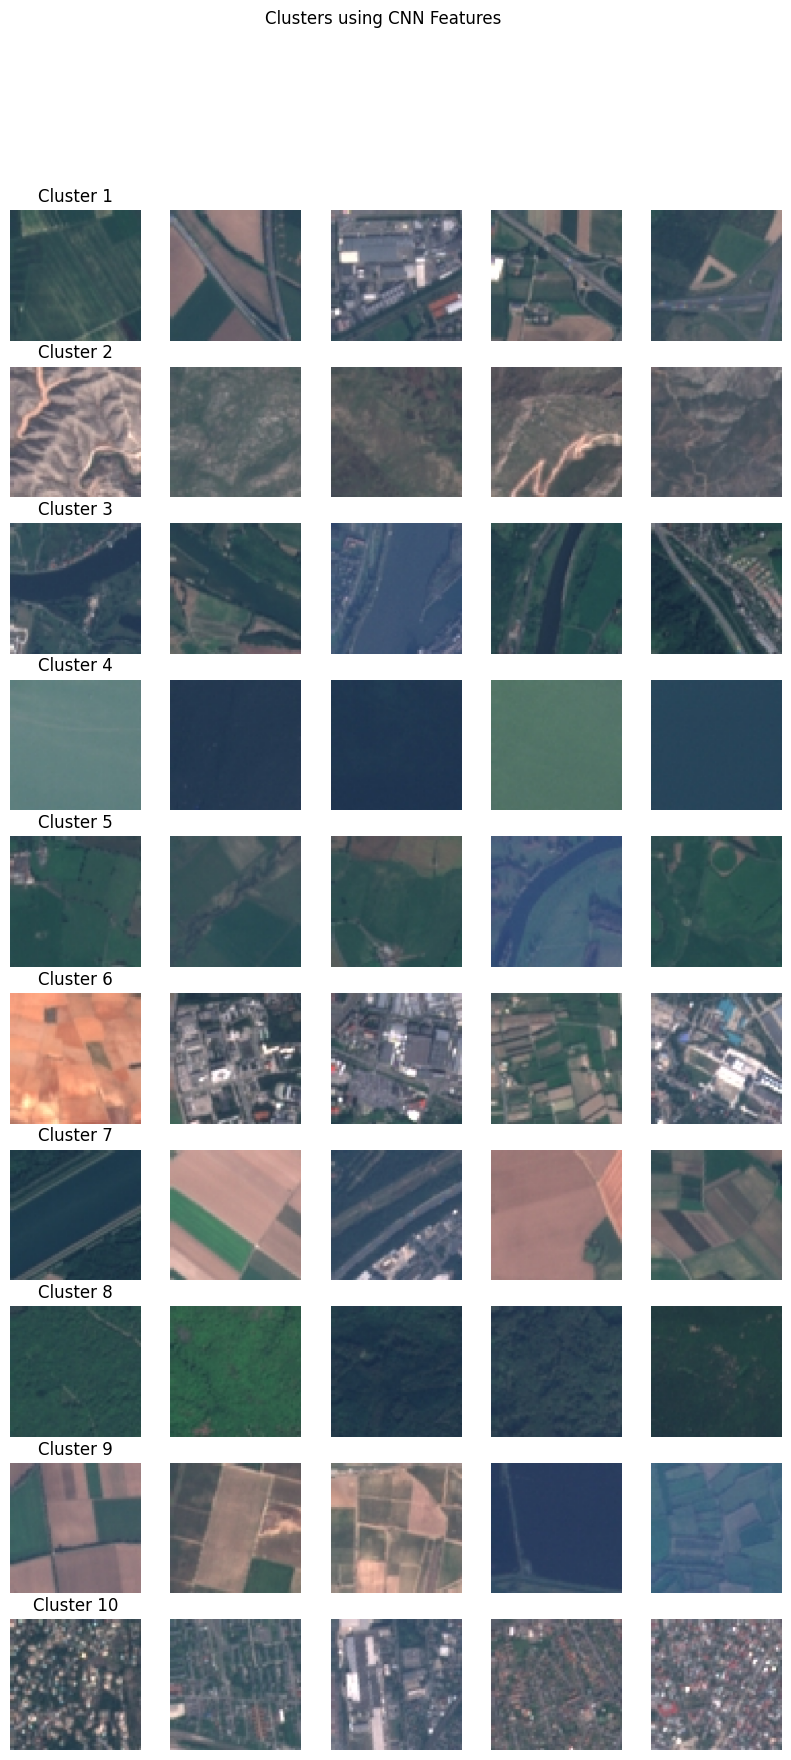

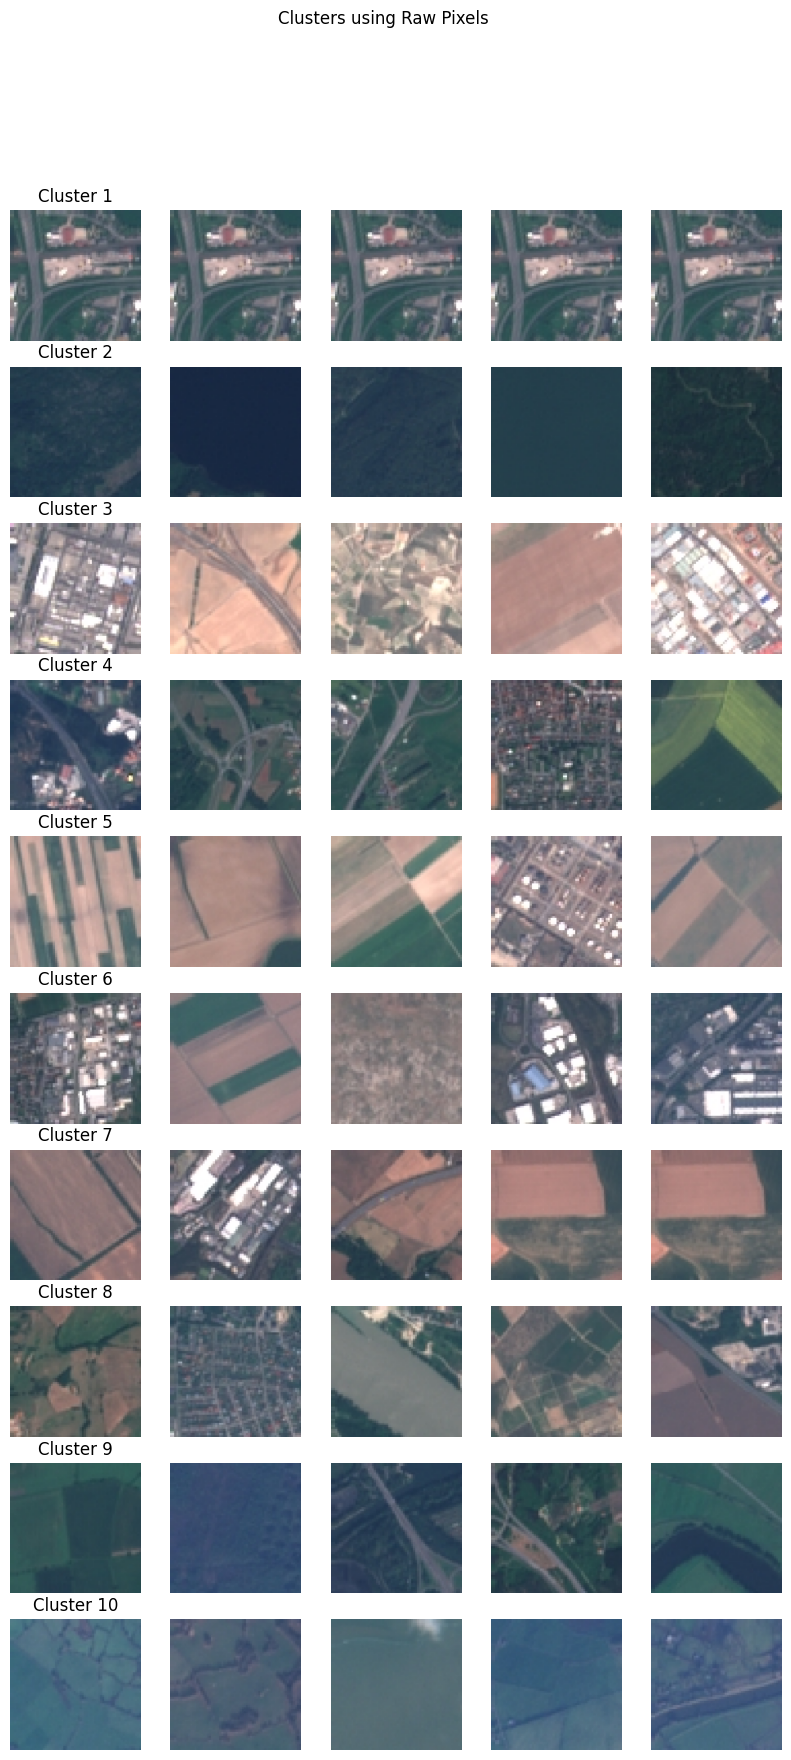

In [36]:
n_clusters=10
n_examples=5
#Clusters using CNN Features
fig_cnn, ax_cnn = plt.subplots(n_clusters, n_examples, figsize=(10, 20))

for cluster_id in range(n_clusters):
  indices=np.where(kmeans_cnn.labels_==cluster_id)[0]
  random_indices=np.random.choice(indices, 5)

  for i in range(n_examples):
    ax=ax_cnn[cluster_id, i]
    img_flat = pixels[random_indices[i]]
    img_reshaped = img_flat.reshape(224, 224, 3)
    ax.imshow(img_reshaped)
    ax.axis('off')
    if i == 0:
      ax.set_title(f'Cluster {cluster_id+1}')
plt.suptitle('Clusters using CNN Features')
plt.show()

print('\n')
#Clusters using Raw Pixels
fig_pixel, ax_pixel = plt.subplots(n_clusters, n_examples, figsize=(10, 20))
for cluster_id in range(n_clusters):
  indices=np.where(kmeans_pixel.labels_==cluster_id)[0]
  random_indices=np.random.choice(indices, 5)

  for i in range(n_examples):
    ax=ax_pixel[cluster_id, i]
    img_flat = pixels[random_indices[i]]
    img_reshaped = img_flat.reshape(224, 224, 3)
    ax.imshow(img_reshaped)
    ax.axis('off')
    if i == 0:
      ax.set_title(f'Cluster {cluster_id+1}')
plt.suptitle('Clusters using Raw Pixels')
plt.show()

> - Η συσταδοποίηση είναι εμφανής και στις δύο περιπτώσεις αλλά πιο έντονα στην περίπτωση του CNN. Σε μία περίπτωση στα Raw Pixels βλέπουμε μία συστάδα να περιέχει την ίδια εικόνα (Cluster 1 για Raw Pixel) που σημαίνει ότι επικρατεί κάποιο χρώμα που δεν βρίσκεται κάπου αλλού στο dataset, αν και θα μπορούσε να το κατατάξει σε κάποιο cluster με κτήρια όπως κάνει πολύ πετυχημένα ο CNN (π.χ. Cluster 10 του CNN)
> - Παρατηρούνται κατά κύριο λόγο κοινά χαρακτηριστικά στις εικόνες που έχουν συσταδοποιηθεί με CNN (π.χ. στο Cluster 2 βλέπουμε βουνά, στο Cluster 3 ποτάμια, στο Cluster 4 θάλασσα, στο Cluster 8 δάση, στο Cluster 10 κατοικημένες περιοχές) με μερικά λάθη βέβαια (π.χ. στο Cluster 6 υπάρχει μία πεδιάδα, κτήρια, αλλά και έρημος). Αντίθετα, στην περίπτωση των Raw Pixels δεν βλέπουμε πολλά κοινά χαρακτηριστικά ως προς το περιεχόμενο των εικόνων αλλά κυρίως στα χρώματα ανά cluster (π.χ. Στο Cluster 2 επικρατεί το βαθύ πράσινο σε δάση από βουνά, αλλά μπερδεύεται και με μία λίμνη/θάλασσα και σε πολλά clusters βλέπουμε να συνυπάρχουν κατοικημένες περιοχές με πεδιάδες και καλλιέργειες γιατί επικρατεί το πράσινο χρώμα όπως στο Cluster 4).